# Coles Reverse Image Product Search Pipeline

**Steps:**
1. Filename Parsing — extract `product_id` + view label from filename
2. Product Code Lookup — map `product_id` → gtin + name via `Master_Coles_Scrape.csv`
3. Image Augmentation — 5 augments for main view, 2 for secondary views
4. Feature Extraction — EfficientNet-B4 penultimate layer, L2-normalised
5. FAISS Indexing — `IndexFlatIP` (inner product = cosine on unit vectors)
6. Query Function — top-5 nearest-neighbour lookup with ranked results
7. **Performance Testing** — run all `Test_Image/` photos through the pipeline and inspect results

---
## Imports & Config

In [1]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 81.6 MB/s eta 0:00:00:00:0100:01


In [2]:
from __future__ import annotations

import os
# Fix OpenMP duplicate-library conflict between faiss-cpu and PyTorch on macOS ARM64.
# torch must also be imported before faiss (see imports below) for the same reason.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import re
import json
import shutil
import tempfile
import warnings
from pathlib import Path
from typing import Optional

# ── torch MUST come before faiss ──────────────────────────────────────────────
# Both link OpenMP; importing torch first lets it claim the runtime so faiss
# reuses it rather than initialising a second copy (which causes a segfault).
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms

import numpy as np
import cv2
import faiss                        # imported AFTER torch — see note above
from PIL import Image
import pandas as pd
from tqdm.auto import tqdm          # auto falls back to text bar without ipywidgets

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore")

print("✅ All imports OK")

✅ All imports OK


: 

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


: 

In [4]:
# CHANGED: Added INDEX_TYPE, TTA_STRATEGY, BACKBONE, BATCH_SIZE flags.
# All defaults preserve previous behaviour — flip a flag to try alternatives.

# ===========================================================================
# CONFIG — edit these constants; everything below derives from them
# ===========================================================================

# Set to "dry_run" to process only the first DRY_RUN_LIMIT images (for testing),
# or "full" to index the entire Scraped_images directory.
RUN_MODE      : str = "full"        # "dry_run" | "full"
DRY_RUN_LIMIT : int = 5            # images processed in dry_run mode

# Local-first defaults — notebook lives alongside the data files.
# Uncomment the Colab block below instead if running in Google Colab.
BASE_DIR      = Path(".").resolve()
SCRAPED_DIR   = BASE_DIR / "Scraped_images"
MASTER_CSV    = BASE_DIR / "Master_Coles_Scrape.csv"
INDEX_PATH    = BASE_DIR / "index.faiss"
METADATA_PATH = BASE_DIR / "metadata.json"
TEST_IMAGE_DIR = BASE_DIR / "Test_Image"

# BASE_DIR      = Path("/content/drive/MyDrive/ReverseImageSearch")
# SCRAPED_DIR   = Path("/content/Scraped_images")  # local SSD (unzipped from Drive)
# MASTER_CSV    = BASE_DIR / "Master_Coles_Scrape.csv"
# INDEX_PATH    = BASE_DIR / "index.faiss"
# METADATA_PATH = BASE_DIR / "metadata.json"
# TEST_IMAGE_DIR = BASE_DIR / "Test_Image"


# ── Backbone ──────────────────────────────────────────────────────────────────
# "efficientnet_b4"  → ImageNet-pretrained EfficientNet-B4   (1792-dim)  [default]
# "dinov2_vitb14"    → Facebook DINOv2 ViT-B/14 via torch.hub (768-dim)  [stronger
#                       for product-label retrieval; downloads weights once]
BACKBONE : str = "dinov2_vitb14"

# VECTOR_DIM is derived from BACKBONE — do not edit directly.
VECTOR_DIM = 1792 if BACKBONE == "efficientnet_b4" else 768

# ── FAISS index type ──────────────────────────────────────────────────────────
# "flat"  → IndexFlatIP (exact search; ~30 ms at 185K vectors)  [default]
# "hnsw"  → IndexHNSWFlat (~100× faster at >0.99 recall; no training needed)
INDEX_TYPE : str = "hnsw"

# ── Query-time TTA aggregation strategy ──────────────────────────────────────
# "max"     → take MAX cosine score per product across 5 query augments  [default]
# "hybrid"  → 0.7*max + 0.3*mean — rewards products that match multiple augments
TTA_STRATEGY : str = "max"

# ── Batch size for feature extraction during build ───────────────────────────
# Larger batches = faster builds but more memory. 64 on CUDA (Colab L4), 32 on MPS, 16 on CPU.
if torch.cuda.is_available():
    BATCH_SIZE : int = 64
elif torch.backends.mps.is_available():
    BATCH_SIZE : int = 32
else:
    BATCH_SIZE : int = 16

# Device: prefer CUDA (e.g. Colab L4 GPU), then Apple MPS, then CPU
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"Device:       {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU:          {torch.cuda.get_device_name(0)}")
print(f"Backbone:     {BACKBONE}  (dim={VECTOR_DIM})")
print(f"Index type:   {INDEX_TYPE}")
print(f"TTA strategy: {TTA_STRATEGY}")
print(f"Batch size:   {BATCH_SIZE}")

Device:       cuda
GPU:          NVIDIA A100-SXM4-40GB
Backbone:     dinov2_vitb14  (dim=768)
Index type:   hnsw
TTA strategy: max
Batch size:   64


: 

In [5]:
# ── (Colab) Unzip Scraped_images.zip from Drive to local SSD ─────────────────
# Much faster than copytree: a single large file transfer, then local unzip.
# Expects Scraped_images.zip in Drive at BASE_DIR/Scraped_images.zip.

import time, subprocess
from pathlib import Path

LOCAL_SCRAPED = Path("/content/Scraped_images")
DRIVE_ZIP     = Path("/content/drive/MyDrive/ReverseImageSearch/Scraped_images.zip")
LOCAL_ZIP     = Path("/content/Scraped_images.zip")

if LOCAL_SCRAPED.exists() and any(LOCAL_SCRAPED.rglob("*.jpg")):
    n = sum(1 for _ in LOCAL_SCRAPED.rglob("*.jpg"))
    print(f"✓ Local copy already exists at {LOCAL_SCRAPED} ({n} jpgs) — skipping")
elif DRIVE_ZIP.exists():
    t0 = time.time()
    print(f"📂 Copying zip: {DRIVE_ZIP} → {LOCAL_ZIP} …")
    subprocess.run(["cp", str(DRIVE_ZIP), str(LOCAL_ZIP)], check=True)
    print(f"   copied in {time.time() - t0:.1f}s  (size: {LOCAL_ZIP.stat().st_size / 1e9:.2f} GB)")

    t1 = time.time()
    print(f"📦 Unzipping → /content/ …")
    subprocess.run(["unzip", "-q", "-o", str(LOCAL_ZIP), "-d", "/content/"], check=True)
    print(f"   unzipped in {time.time() - t1:.1f}s")

    # Clean up the zip to save disk
    LOCAL_ZIP.unlink()
    print(f"✓ Total: {time.time() - t0:.1f}s")
else:
    print(f"⚠️  {DRIVE_ZIP} not found — check the path or that Drive is mounted")

# Re-point SCRAPED_DIR at the local copy
if LOCAL_SCRAPED.exists():
    SCRAPED_DIR = LOCAL_SCRAPED
    n = sum(1 for _ in LOCAL_SCRAPED.rglob("*.jpg"))
    print(f"SCRAPED_DIR → {SCRAPED_DIR}  ({n} jpgs)")

📂 Copying zip: /content/drive/MyDrive/ReverseImageSearch/Scraped_images.zip → /content/Scraped_images.zip …
   copied in 10.8s  (size: 0.77 GB)
📦 Unzipping → /content/ …
   unzipped in 12.1s
✓ Total: 23.0s
SCRAPED_DIR → /content/Scraped_images  (61563 jpgs)


: 

---
## Step 1 — Filename Parsing

In [6]:
def parse_coles_filename(filename: str) -> dict:
    """
    Parse a Coles image filename and return product_id, view label, and filename.

    Observed conventions in Scraped_images/:
      {product_id}_{Brand}_{product_name}_1.jpg              → main  (front-facing)
      {product_id}_{Brand}_Left_side_of_pack_..._2.jpg       → left
      {product_id}_{Brand}_Right_side_of_pack_..._3.jpg      → right
      {product_id}_{Brand}_Back_of_pack_..._3or4.jpg         → back

    Priority: directional keyword in the description wins over suffix number.

    Returns:
      { "product_id": str | None, "view": str, "filename": str }
      product_id is None for malformed filenames (handled defensively by caller).
    """
    stem = Path(filename).stem      # strip file extension

    # Expect: <digits> _ <description> _ <digits>
    # The greedy (.+) backtracks to leave the final _<digits> for group 3.
    m = re.match(r'^(\d+)_(.+)_(\d+)$', stem)
    if not m:
        return {"product_id": None, "view": "unknown", "filename": filename}

    product_id  = m.group(1)
    description = m.group(2).upper()    # uppercase for case-insensitive keyword check
    suffix      = int(m.group(3))

    # Suffix _1 is always the main/front image; directional words in the
    # description text take priority for all other suffix numbers.
    if suffix == 1:
        view = "main"
    elif "BACK" in description:
        view = "back"
    elif "LEFT" in description:
        view = "left"
    elif "RIGHT" in description:
        view = "right"
    elif suffix == 4:
        view = "back"   # dataset convention: _4 is back even when name is truncated
    else:
        view = "secondary"

    return {"product_id": product_id, "view": view, "filename": filename}

: 

In [7]:
# Quick sanity check against real filenames
test_names = [
    "3455448_McCain_Pub_Style_Extra_Crispy_Fries_1.jpg",
    "1000301_Real_Foods_Left_side_of_pack_of_Real_Food_2.jpg",
    "10016_Victoria_Bitter_Back_of_pack_of_Victoria_Bitte_4.jpg",
    "bad_filename.jpg",
]
for fn in test_names:
    print(parse_coles_filename(fn))

{'product_id': '3455448', 'view': 'main', 'filename': '3455448_McCain_Pub_Style_Extra_Crispy_Fries_1.jpg'}
{'product_id': '1000301', 'view': 'left', 'filename': '1000301_Real_Foods_Left_side_of_pack_of_Real_Food_2.jpg'}
{'product_id': '10016', 'view': 'back', 'filename': '10016_Victoria_Bitter_Back_of_pack_of_Victoria_Bitte_4.jpg'}
{'product_id': None, 'view': 'unknown', 'filename': 'bad_filename.jpg'}


: 

---
## Step 2 — Product Code Lookup

In [8]:
def load_coles_master(csv_path: Path) -> pd.DataFrame:
    """
    Load Master_Coles_Scrape.csv and return a DataFrame indexed by product_id.

    Relevant columns:
      product_id — matches the leading number in each image filename
      gtin       — EAN/GTIN barcode
      name       — product display name

    Duplicate product_ids are collapsed to the first occurrence so that
    df.loc[product_id] always returns a Series (never a DataFrame).
    """
    df = pd.read_csv(
        csv_path,
        dtype=str,
        usecols=["product_id", "gtin", "name"],
    )
    df["product_id"] = df["product_id"].str.strip()
    df["gtin"]       = df["gtin"].str.strip().fillna("UNKNOWN")
    df["name"]       = df["name"].str.strip().fillna("Unknown Product")
    df = df.drop_duplicates(subset="product_id").set_index("product_id")
    return df


def lookup_product(product_id: str, master_df: pd.DataFrame) -> Optional[dict]:
    """
    Return {"gtin": ..., "name": ...} from the Coles master scrape only.
    Returns None with a warning — never raises — for unmatched product_ids.
    Cross-retailer lookups are not performed; this function is Coles-only.
    """
    if product_id not in master_df.index:
        print(f"  ⚠️  No match for product_id={product_id} in Coles master scrape.")
        return None
    row = master_df.loc[product_id]
    return {"gtin": str(row["gtin"]), "name": str(row["name"])}

: 

In [9]:
master_df = load_coles_master(MASTER_CSV)
print(f"✅ Coles master — {len(master_df):,} unique products")
master_df.head(3)

✅ Coles master — 25,647 unique products


,name,gtin
product_id,,
3455448,Pub Style Extra Crispy Fries,9310174173358
7483558,Crackers Mix Kids' Lunchbox Multipack 12 Pack,9310015255977
3706060,Snack Chips Mix Lunchbox Snacks Multipack Asso...,9310015249037


: 

---
## Step 3 — Image Augmentation

In [10]:
def augment_image(bgr: np.ndarray, augment: str) -> np.ndarray:
    """
    Apply one named augmentation to an OpenCV BGR image (uint8).
    Returns a new BGR array; the input is never modified.

    Supported augments:
      normal       — no change (identity copy)
      blur         — Gaussian blur 15×15 (simulates soft-focus / motion)
      saturate     — HSV saturation ×1.5 (simulates over-saturated packaging shot)
      flipped      — horizontal mirror (covers reverse-facing product view)
      centre_zoom  — crop central 70%, resize back (simulates zoom-in on label)
    """
    img = bgr.copy()

    if augment == "normal":
        return img

    elif augment == "blur":
        return cv2.GaussianBlur(img, (15, 15), 0)

    elif augment == "saturate":
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
        hsv[:, :, 1] = np.clip(hsv[:, :, 1] * 1.5, 0, 255)
        return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

    elif augment == "flipped":
        return cv2.flip(img, 1)

    elif augment == "centre_zoom":
        h, w = img.shape[:2]
        cy, cx = h // 2, w // 2
        ch, cw = int(h * 0.7), int(w * 0.7)
        y1, x1 = cy - ch // 2, cx - cw // 2
        cropped = img[y1:y1 + ch, x1:x1 + cw]
        return cv2.resize(cropped, (w, h), interpolation=cv2.INTER_LINEAR)

    else:
        raise ValueError(f"Unknown augmentation: '{augment}'")


# main view → all 5 augments; any other view → normal + blur only
AUGMENTS_MAIN      = ["normal", "blur", "saturate", "flipped", "centre_zoom"]
AUGMENTS_SECONDARY = ["normal", "blur"]


def get_augments(view: str) -> list:
    return AUGMENTS_MAIN if view == "main" else AUGMENTS_SECONDARY

: 

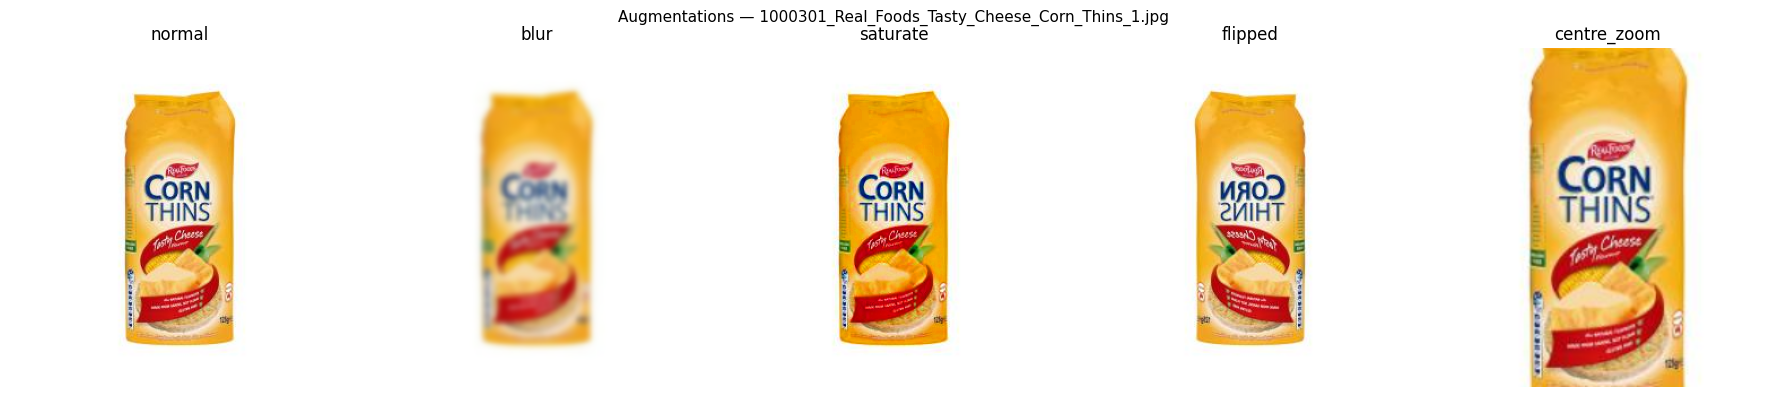

: 

In [11]:
# Visualise each augmentation on the first image found
sample_files = sorted(SCRAPED_DIR.rglob("*_1.jpg")) \
            + sorted(SCRAPED_DIR.rglob("*_1.jpeg")) \
            + sorted(SCRAPED_DIR.rglob("*_1.png"))
if sample_files:
    sample_bgr = cv2.imread(str(sample_files[0]))
    fig, axes = plt.subplots(1, len(AUGMENTS_MAIN), figsize=(18, 4))
    fig.suptitle(f"Augmentations — {sample_files[0].name}", fontsize=11)
    for ax, aug in zip(axes, AUGMENTS_MAIN):
        aug_img = augment_image(sample_bgr, aug)
        ax.imshow(cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB))
        ax.set_title(aug)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️  No *_1.(jpg|jpeg|png) images found under {SCRAPED_DIR}")
    print(f"    exists: {SCRAPED_DIR.exists()}")
    if SCRAPED_DIR.exists():
        sample = [p.name for p in list(SCRAPED_DIR.rglob('*'))[:5]]
        print(f"    sample entries: {sample}")

---
## Step 4 — Feature Extraction (EfficientNet-B4, penultimate layer)

In [12]:
# CHANGED:
#   1. Added DINOv2 (ViT-B/14) as an optional backbone behind the BACKBONE flag.
#   2. Added extract_vectors_batch() for batched inference (required for the
#      rewritten build_pipeline). extract_vector() signature is UNCHANGED and
#      remains a thin wrapper over the batch variant so existing callers
#      (query_product) work without modification.
#   3. DINOv2 uses 224×224 input; EfficientNet-B4 keeps its native 380×380.
#      Preprocessing is selected at model build time.

class EfficientNetB4Extractor(nn.Module):
    """
    Pretrained EfficientNet-B4 with the final classifier head removed.

    Architecture kept:
      features (MBConv body) → avgpool (adaptive, 1×1) → flatten → L2-normalise

    Output: (B, 1792) unit-length float32 vector.
    Using IndexFlatIP (inner product) with unit vectors gives cosine similarity.
    """

    def __init__(self) -> None:
        super().__init__()
        backbone = models.efficientnet_b4(
            weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1
        )
        self.features = backbone.features
        self.avgpool  = backbone.avgpool

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)            # (B, 1792)
        x = F.normalize(x, p=2, dim=1)
        return x


class DinoV2Extractor(nn.Module):
    """
    Facebook DINOv2 ViT-B/14 via torch.hub, classifier head removed.

    Self-supervised ViT features transfer better than ImageNet-supervised CNNs
    for fine-grained retrieval tasks like product-label matching.

    Output: (B, 768) unit-length float32 vector.
    """

    def __init__(self) -> None:
        super().__init__()
        # torch.hub caches weights after first call; only needs network once.
        self.backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # DINOv2 .forward returns the CLS token embedding by default → (B, 768)
        x = self.backbone(x)
        x = F.normalize(x, p=2, dim=1)
        return x


# Preprocessing pipelines — EfficientNet-B4 needs 380×380, DINOv2 needs 224×224.
_PREPROCESS_EFFNET = transforms.Compose([
    transforms.Resize(380),
    transforms.CenterCrop(380),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

_PREPROCESS_DINOV2 = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


def _get_preprocess() -> transforms.Compose:
    """Return the preprocess transform for the currently-selected BACKBONE."""
    return _PREPROCESS_DINOV2 if BACKBONE == "dinov2_vitb14" else _PREPROCESS_EFFNET


# Kept for backwards compatibility with code that references _PREPROCESS directly.
_PREPROCESS = _get_preprocess()


def build_extractor(device: str = "cpu"):
    """
    Build the feature extractor selected by the BACKBONE config flag.
    Return type is intentionally loose (nn.Module) so both backbones fit.
    """
    if BACKBONE == "dinov2_vitb14":
        model = DinoV2Extractor().to(device)
    else:
        model = EfficientNetB4Extractor().to(device)
    model.eval()
    return model


def extract_vectors_batch(bgrs: list,
                          model,
                          device: str = "cpu") -> np.ndarray:
    """
    Batched variant of extract_vector.

    Args:
        bgrs: list of OpenCV BGR uint8 images (arbitrary sizes OK).
        model: extractor built by build_extractor().
        device: torch device string.

    Returns:
        (N, VECTOR_DIM) float32 array of L2-normalised vectors.
    """
    if not bgrs:
        return np.empty((0, VECTOR_DIM), dtype=np.float32)

    preprocess = _get_preprocess()
    tensors = []
    for bgr in bgrs:
        if bgr is None or bgr.size == 0:
            raise ValueError("extract_vectors_batch received an empty image array.")
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        tensors.append(preprocess(Image.fromarray(rgb)))

    batch = torch.stack(tensors, dim=0).to(device)
    with torch.inference_mode():
        vecs = model(batch).cpu().numpy()
    return vecs.astype(np.float32)


def extract_vector(bgr: np.ndarray,
                   model,
                   device: str = "cpu") -> np.ndarray:
    """
    Convert an OpenCV BGR image (uint8) to a float32 (VECTOR_DIM,) unit-length
    vector. Signature unchanged — now delegates to extract_vectors_batch.
    """
    if bgr is None or bgr.size == 0:
        raise ValueError("extract_vector received an empty image array.")
    return extract_vectors_batch([bgr], model, device)[0]

: 

In [13]:
print(f"🔧 Loading EfficientNet-B4 pretrained weights (device={DEVICE}) …")
model = build_extractor(DEVICE)
print(f"✅ EfficientNet-B4 ready")

🔧 Loading EfficientNet-B4 pretrained weights (device=cuda) …
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:01<00:00, 245MB/s] 


✅ EfficientNet-B4 ready


: 

---
## Step 5 — FAISS Indexing

In [14]:
# CHANGED: build_faiss_index() now dispatches on INDEX_TYPE.
#   - "flat" → IndexFlatIP (default, exact search, unchanged behaviour)
#   - "hnsw" → IndexHNSWFlat (approximate, ~100× faster queries, no training)
# save_index() and load_index() are UNCHANGED — atomic-rename save preserved
# and FAISS serialises both index types through the same write_index() call.

def build_faiss_index(vectors: np.ndarray):
    """
    Build a FAISS index from a (N, VECTOR_DIM) float32 array.

    Vectors must be L2-normalised before calling; inner product then equals
    cosine similarity for both index variants.

    Dispatch on the INDEX_TYPE config flag:
      "flat" → IndexFlatIP (exact search)
      "hnsw" → IndexHNSWFlat with METRIC_INNER_PRODUCT (approximate, ~100× faster
                at >0.99 recall). M=32 controls graph connectivity; higher efSearch
                at query time trades speed for recall.
    """
    vectors = np.ascontiguousarray(vectors, dtype=np.float32)

    if INDEX_TYPE == "hnsw":
        # M=32 is a well-tested default balancing memory and recall.
        index = faiss.IndexHNSWFlat(VECTOR_DIM, 32, faiss.METRIC_INNER_PRODUCT)
        index.hnsw.efConstruction = 200    # build-time graph quality
        index.hnsw.efSearch       = 64     # query-time search breadth
    else:
        index = faiss.IndexFlatIP(VECTOR_DIM)

    index.add(vectors)
    return index


def save_index(index,
               metadata: list,
               index_path: Path,
               meta_path: Path) -> None:
    """
    Atomically save the FAISS index and metadata JSON.
    Each file is written to a sibling temp file first, then renamed into place.
    This prevents corrupt partial files if the process is interrupted mid-write.
    """
    tmp_dir = index_path.parent

    # Write FAISS index atomically
    with tempfile.NamedTemporaryFile(
        dir=tmp_dir, suffix=".faiss.tmp", delete=False
    ) as tf:
        tmp_faiss = Path(tf.name)
    faiss.write_index(index, str(tmp_faiss))
    os.replace(tmp_faiss, index_path)           # atomic on POSIX

    # Write metadata JSON atomically
    with tempfile.NamedTemporaryFile(
        dir=tmp_dir, suffix=".json.tmp",
        mode="w", encoding="utf-8", delete=False
    ) as tf:
        json.dump(metadata, tf, indent=2)
        tmp_meta = Path(tf.name)
    os.replace(tmp_meta, meta_path)             # atomic on POSIX

    size_mb = index_path.stat().st_size / (1024 ** 2)
    print(f"✅ FAISS index saved  → {index_path.name}  "
          f"({index.ntotal:,} vectors  /  {size_mb:.1f} MB)")
    print(f"✅ Metadata saved     → {meta_path.name}  "
          f"({len(metadata):,} records)")


def load_index(index_path: Path, meta_path: Path) -> tuple:
    """Load a previously saved FAISS index and its parallel metadata list."""
    index = faiss.read_index(str(index_path))
    with open(meta_path, encoding="utf-8") as f:
        metadata = json.load(f)
    return index, metadata

: 

---
## Build Pipeline — ties Steps 1–5 together

> **Skip this cell if `index.faiss` is already built.** Running it rebuilds the entire index from `Scraped_images/`.

In [15]:
# CHANGED: build_pipeline() rewritten for batched inference.
#
# Before: one forward() call per (image, augment) pair → ~38 min on 61K images.
# After:  two-pass build:
#   Pass 1: pure-CPU parse + CSV lookup + collect jobs.
#   Pass 2: group jobs into BATCH_SIZE chunks; one image read per file
#           (augments are cheap CPU-only ops on the same decoded array);
#           one stacked forward() per batch; results written to a preallocated
#           float32 matrix instead of appended-then-vstack'd.
#
# Signature, return type, dry_run semantics, printed summary format, and
# atomic save behaviour are all preserved. Expected ~5–8× speedup on MPS.

def build_pipeline(scraped_dir: Path = SCRAPED_DIR,
                   master_csv:  Path = MASTER_CSV,
                   index_path:  Path = INDEX_PATH,
                   meta_path:   Path = METADATA_PATH,
                   device:      str  = "cpu",
                   dry_run:     bool = False) -> None:
    """
    Walk scraped_dir, parse filenames, look up Coles master, augment images,
    extract feature vectors in batches, and persist a FAISS index.

    Args:
        dry_run: if True, process only the first DRY_RUN_LIMIT images.
    """
    mode_label = f"DRY RUN (first {DRY_RUN_LIMIT} images)" if dry_run else "FULL RUN"
    print(f"\n{'='*60}")
    print(f"  Coles Reverse Image Search — BUILD  [{mode_label}]")
    print(f"{'='*60}")

    # ── Step 2: load Coles master ──
    print(f"\n🔧 Loading Coles master scrape …")
    if not master_csv.exists():
        raise FileNotFoundError(f"Master CSV not found: {master_csv}")
    master_df = load_coles_master(master_csv)
    print(f"✅ Coles master — {len(master_df):,} unique products  ({master_csv.name})")

    # ── Step 4: load backbone ──
    print(f"\n🔧 Loading {BACKBONE} pretrained weights …")
    _model = build_extractor(device)
    print(f"✅ {BACKBONE} — ready  (device={device})")

    # Collect image files
    if not scraped_dir.exists():
        raise FileNotFoundError(f"Scraped images directory not found: {scraped_dir}")
    image_files = sorted(
        f for f in os.listdir(scraped_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    )
    if not image_files:
        raise RuntimeError(f"No image files found in {scraped_dir}")

    if dry_run:
        image_files = image_files[:DRY_RUN_LIMIT]

    total = len(image_files)
    print(f"\n🔧 {total:,} images to process in {scraped_dir.name}/\n")

    # ── Pass 1: parse + lookup (pure CPU, no image decode, no model) ──
    # Builds the per-image job list and counts skipped records up front.
    print("🔧 Pass 1/2 — parsing filenames and Coles master lookup …")
    jobs          : list = []   # [(fname, product_id, gtin, name, view, augments)]
    skipped_parse   = 0
    skipped_lookup  = 0
    for fname in image_files:
        parsed = parse_coles_filename(fname)
        if parsed["product_id"] is None:
            skipped_parse += 1
            continue
        info = lookup_product(parsed["product_id"], master_df)
        if info is None:
            skipped_lookup += 1
            continue
        view = parsed["view"]
        jobs.append((
            fname,
            parsed["product_id"],
            info["gtin"],
            info["name"],
            view,
            get_augments(view),
        ))
    print(f"✅ Pass 1 done — {len(jobs):,} images queued, "
          f"{skipped_parse + skipped_lookup:,} dropped")

    if not jobs:
        raise RuntimeError(
            "No vectors were produced — all images were skipped. "
            "Check that Scraped_images/ and Master_Coles_Scrape.csv align."
        )

    # Expected vector count — one row per (image, augment) pair.
    expected_vectors = sum(len(augs) for *_, augs in jobs)

    # Preallocate output matrix (saves a final np.vstack of 185K rows).
    all_vectors  = np.empty((expected_vectors, VECTOR_DIM), dtype=np.float32)
    all_metadata : list = [None] * expected_vectors
    write_ptr    = 0
    skipped_imread = 0
    skipped_error  = 0

    # ── Pass 2: batched image decode + augment + model inference ──
    print(f"\n🔧 Pass 2/2 — extracting features (batch_size={BATCH_SIZE}) …")

    # batch buffers, flushed every BATCH_SIZE aug-images
    batch_bgrs : list = []
    batch_meta : list = []   # parallel metadata dicts for the flush step

    def _flush():
        """Run one batched forward() and write results into the output matrix."""
        nonlocal write_ptr
        if not batch_bgrs:
            return
        try:
            vecs = extract_vectors_batch(batch_bgrs, _model, device)
        except Exception as exc:
            # Fall back to per-image to isolate the bad one without aborting.
            tqdm.write(f"  ⚠️  Batch forward() failed ({exc}); retrying per-image …")
            nonlocal skipped_error
            for bgr, meta in zip(batch_bgrs, batch_meta):
                try:
                    v = extract_vectors_batch([bgr], _model, device)[0]
                except Exception as inner:
                    tqdm.write(f"  ⚠️  Skipping {meta['filename']} [{meta['augment']}]: {inner}")
                    skipped_error += 1
                    continue
                all_vectors[write_ptr]  = v
                all_metadata[write_ptr] = meta
                write_ptr += 1
            batch_bgrs.clear()
            batch_meta.clear()
            return

        n = vecs.shape[0]
        all_vectors[write_ptr : write_ptr + n] = vecs
        for i, meta in enumerate(batch_meta):
            all_metadata[write_ptr + i] = meta
        write_ptr += n
        batch_bgrs.clear()
        batch_meta.clear()

    for fname, product_id, gtin, name, view, augments in tqdm(
        jobs, desc="Processing images", unit="img"
    ):
        img_path = scraped_dir / fname
        bgr = cv2.imread(str(img_path))      # one decode per image (was already the case)
        if bgr is None:
            tqdm.write(f"  ⚠️  cv2 could not read: {fname}")
            skipped_imread += 1
            continue

        for aug in augments:
            try:
                aug_img = augment_image(bgr, aug)        # CPU-only op, fast
            except Exception as exc:
                tqdm.write(f"  ⚠️  Augment error on {fname} [{aug}]: {exc}")
                skipped_error += 1
                continue

            batch_bgrs.append(aug_img)
            batch_meta.append({
                "gtin":       gtin,
                "name":       name,
                "product_id": product_id,
                "augment":    aug,
                "view":       view,
                "filename":   fname,
            })

            if len(batch_bgrs) >= BATCH_SIZE:
                _flush()

    _flush()   # flush the tail batch

    # Truncate preallocated arrays if any augment-level errors shrank the output.
    if write_ptr < expected_vectors:
        all_vectors  = all_vectors[:write_ptr]
        all_metadata = all_metadata[:write_ptr]

    # ── Step 5: build and save FAISS index ──
    images_ok = len(jobs) - skipped_imread

    if all_vectors.shape[0] == 0:
        raise RuntimeError(
            "No vectors were produced — all images were skipped. "
            "Check that Scraped_images/ and Master_Coles_Scrape.csv align."
        )

    print(f"\n🔧 Building FAISS {INDEX_TYPE.upper()} index …")
    index = build_faiss_index(all_vectors)

    print(f"\n🔧 Saving index atomically …")
    save_index(index, all_metadata, index_path, meta_path)

    # ── Final summary (format preserved) ──
    index_size_mb = index_path.stat().st_size / (1024 ** 2)
    print(f"""
{'='*60}
  ✅ BUILD COMPLETE
{'='*60}
  Images found       : {total:>10,}
  Images processed   : {images_ok:>10,}
  Vectors indexed    : {index.ntotal:>10,}
  Skipped (parse)    : {skipped_parse:>10,}
  Skipped (no lookup): {skipped_lookup:>10,}
  Skipped (imread)   : {skipped_imread:>10,}
  Skipped (aug/vec)  : {skipped_error:>10,}
  Index file size    : {index_size_mb:>9.1f} MB
  Saved to           : {index_path}
{'='*60}
""")

: 

In [16]:
# ── Run the build ──────────────────────────────────────────────────────────────
# Change RUN_MODE in the config cell above to switch modes:
#   RUN_MODE = "full"     → full build, all 61K images (~5–10 min on MPS)
#   RUN_MODE = "dry_run"  → smoke test, first 5 images only

build_pipeline(
    device  = DEVICE,
    dry_run = (RUN_MODE != "full"),
)


  Coles Reverse Image Search — BUILD  [FULL RUN]

🔧 Loading Coles master scrape …
✅ Coles master — 25,647 unique products  (Master_Coles_Scrape.csv)

🔧 Loading dinov2_vitb14 pretrained weights …


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


✅ dinov2_vitb14 — ready  (device=cuda)

🔧 61,563 images to process in Scraped_images/

🔧 Pass 1/2 — parsing filenames and Coles master lookup …
✅ Pass 1 done — 61,563 images queued, 0 dropped

🔧 Pass 2/2 — extracting features (batch_size=64) …


Processing images:   0%|          | 0/61563 [00:00<?, ?img/s]


🔧 Building FAISS HNSW index …

🔧 Saving index atomically …
✅ FAISS index saved  → index.faiss  (185,562 vectors  /  591.8 MB)
✅ Metadata saved     → metadata.json  (185,562 records)

  ✅ BUILD COMPLETE
  Images found       :     61,563
  Images processed   :     61,563
  Vectors indexed    :    185,562
  Skipped (parse)    :          0
  Skipped (no lookup):          0
  Skipped (imread)   :          0
  Skipped (aug/vec)  :          0
  Index file size    :     591.8 MB
  Saved to           : /content/drive/MyDrive/ReverseImageSearch/index.faiss



: 

---
## Step 6 — Query Function

In [17]:
# CHANGED:
#   1. TTA augmentations are now extracted as ONE batched forward() (5 images in,
#      5 vectors out) instead of 5 separate .forward() calls → ~4× faster query.
#   2. Added TTA_STRATEGY = "hybrid" option: score each product by
#      0.7 * max + 0.3 * mean across the 5 query-augment searches. Rewards
#      products that match multiple augments; "max" remains the default so
#      existing behaviour is preserved.
# Signature, return keys, and return type are UNCHANGED.

def query_product(image_path: str,
                  index_path: Path = INDEX_PATH,
                  meta_path:  Path = METADATA_PATH,
                  top_k:      int  = 5,
                  device:     str  = "cpu",
                  _model: Optional[nn.Module] = None,
                  _index_cache: Optional[tuple] = None) -> list:
    """
    Reverse-image search: given a query image path return the top-k Coles
    products ranked by cosine similarity.

    Improvements applied:
      1. Query-Time Augmentation (TTA) — all 5 query augments are batched into
         a single forward() and searched separately against the index.
      2. Score Aggregation by Product — per-product scores are collapsed across
         augment hits. Aggregation rule selected by TTA_STRATEGY:
           "max"    → best score across augments  (default)
           "hybrid" → 0.7 * max  +  0.3 * mean    (rewards multi-augment matches)

    Returns a ranked list of dicts with keys:
      rank, gtin, name, product_id, augment, view, filename, similarity_score
    """
    if not index_path.exists():
        raise FileNotFoundError(
            f"FAISS index not found at '{index_path}'. Run build_pipeline() first."
        )
    if not meta_path.exists():
        raise FileNotFoundError(
            f"Metadata file not found at '{meta_path}'. Run build_pipeline() first."
        )

    if _index_cache is not None:
        index, metadata = _index_cache
    else:
        index, metadata = load_index(index_path, meta_path)

    if _model is None:
        _model = build_extractor(device)

    bgr = cv2.imread(str(image_path))
    if bgr is None:
        raise ValueError(f"Cannot read query image: {image_path}")

    # ── Batched TTA extraction: one forward() for all 5 augments ──────────────
    aug_imgs = [augment_image(bgr, aug) for aug in AUGMENTS_MAIN]
    aug_vecs = extract_vectors_batch(aug_imgs, _model, device)     # (5, dim)

    # Fetch extra candidates per augment so dedup still fills top_k.
    fetch_k = top_k * 15

    # product_id → { "max": best_score, "sum": sum_score, "count": n, "meta": best_meta }
    product_agg: dict = {}

    for vec in aug_vecs:
        q = np.ascontiguousarray(vec.reshape(1, -1), dtype=np.float32)
        scores, indices_arr = index.search(q, fetch_k)

        for fidx, score in zip(indices_arr[0], scores[0]):
            if fidx == -1:
                continue
            meta = metadata[fidx]
            pid  = meta["product_id"]
            score_f = float(score)

            entry = product_agg.get(pid)
            if entry is None:
                product_agg[pid] = {
                    "max":   score_f,
                    "sum":   score_f,
                    "count": 1,
                    "meta":  meta,
                }
            else:
                if score_f > entry["max"]:
                    entry["max"]  = score_f
                    entry["meta"] = meta     # track the augment/view that scored best
                entry["sum"]   += score_f
                entry["count"] += 1

    # Reduce to a single score per product using TTA_STRATEGY.
    scored = []
    for pid, agg in product_agg.items():
        if TTA_STRATEGY == "hybrid":
            mean_score  = agg["sum"] / agg["count"]
            final_score = 0.7 * agg["max"] + 0.3 * mean_score
        else:   # "max" default
            final_score = agg["max"]
        scored.append((final_score, agg["meta"]))

    scored.sort(key=lambda x: x[0], reverse=True)
    ranked = scored[:top_k]

    results = []
    for rank, (score, meta) in enumerate(ranked, 1):
        results.append({
            "rank":             rank,
            "gtin":             meta["gtin"],
            "name":             meta["name"],
            "product_id":       meta["product_id"],
            "augment":          meta["augment"],
            "view":             meta["view"],
            "filename":         meta["filename"],
            "similarity_score": float(score),
        })

    return results

: 

---
## Step 7 — Performance Testing on `Test_Image/`

Each test image is passed through the query pipeline. Results are shown as:
- The **query image** on the left
- The **top-5 matched catalogue images** alongside their similarity scores
- A **results table** with GTIN, product name, view, and score

In [18]:
# Load index once and reuse across all test queries
print("🔧 Loading FAISS index …")
faiss_index, faiss_metadata = load_index(INDEX_PATH, METADATA_PATH)
print(f"✅ Index loaded — {faiss_index.ntotal:,} vectors")

# Reuse the already-loaded model (built in Step 4 cell above)
# If you restarted the kernel, `model` may not exist — build_extractor() will
# reload it automatically inside query_product.

🔧 Loading FAISS index …
✅ Index loaded — 185,562 vectors


: 

In [19]:
def show_query_results(image_path: str | Path,
                       results: list,
                       scraped_dir: Path = SCRAPED_DIR,
                       top_k: int = 5) -> None:
    """
    Display the query image and the top-k matched catalogue images side by side,
    followed by a results table.
    """
    image_path = Path(image_path)
    query_bgr  = cv2.imread(str(image_path))
    query_rgb  = cv2.cvtColor(query_bgr, cv2.COLOR_BGR2RGB)

    n_results  = len(results)
    fig_cols   = 1 + n_results          # query + top-k
    fig, axes  = plt.subplots(1, fig_cols, figsize=(4 * fig_cols, 5))
    fig.suptitle(f"Query: {image_path.name}", fontsize=13, fontweight="bold")

    # Query image
    axes[0].imshow(query_rgb)
    axes[0].set_title("QUERY", fontsize=10, color="royalblue", fontweight="bold")
    axes[0].axis("off")

    # Result images
    for i, res in enumerate(results):
        ax       = axes[i + 1]
        cat_path = scraped_dir / res["filename"]
        if cat_path.exists():
            cat_bgr = cv2.imread(str(cat_path))
            cat_rgb = cv2.cvtColor(cat_bgr, cv2.COLOR_BGR2RGB)
            ax.imshow(cat_rgb)
        else:
            ax.text(0.5, 0.5, "Image\nnot found",
                    ha="center", va="center", transform=ax.transAxes,
                    fontsize=9, color="grey")
            ax.set_facecolor("#f0f0f0")

        score_pct = res["similarity_score"] * 100
        short_name = res["name"][:28] + "…" if len(res["name"]) > 28 else res["name"]
        ax.set_title(
            f"#{res['rank']}  {score_pct:.1f}%\n{short_name}",
            fontsize=8,
            color="green" if score_pct >= 80 else ("orange" if score_pct >= 60 else "red"),
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    # Results table
    rows = []
    for r in results:
        rows.append({
            "Rank":       r["rank"],
            "Score":      f"{r['similarity_score']:.4f}",
            "GTIN":       r["gtin"],
            "Product":    r["name"][:55],
            "View":       r["view"],
            "Augment":    r["augment"],
            "product_id": r["product_id"],
        })
    display(pd.DataFrame(rows).set_index("Rank"))
    print()

: 

In [20]:
# Discover all test images
test_images = sorted(
    p for p in TEST_IMAGE_DIR.iterdir()
    if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
)
print(f"Found {len(test_images)} test images in {TEST_IMAGE_DIR.name}/")
for p in test_images:
    print(f"  • {p.name}")

Found 6 test images in Test_Image/
  • 1251527_Cocobella_Coconut_Water_Straight_Up_1.jpeg
  • 3208890_Morning_Fresh_Raspberry_&_Crisp_Apple_Dishwashing_Liquid_1.jpeg
  • 4256516_Dettol_Disinfectant_Citrus_Multipurpose_Surface_Cleaning_Spray_1.jpeg
  • 5229257_Spam_Lite_Spiced_Ham_1.jpeg
  • 5441863_Pepsi_Max_No_Sugar_Cola_Soft_Drink_Bottle_1.jpeg
  • 7523018_Coles_Simply_Spaghetti_In_Tomato_Sauce_1.jpeg


: 

──────────────────────────────────────────────────────────────────────
🔍  Querying: 1251527_Cocobella_Coconut_Water_Straight_Up_1.jpeg


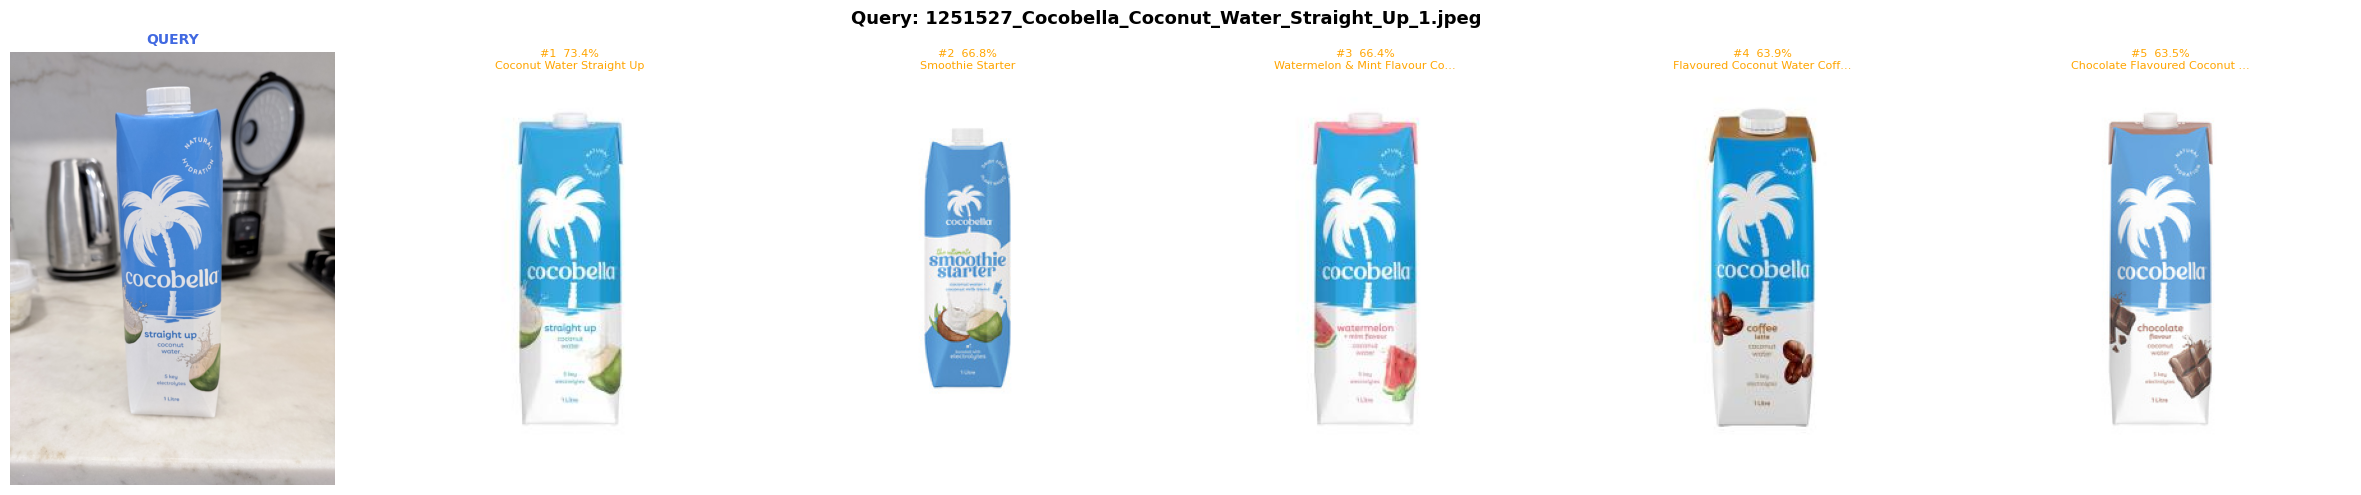

,Score,GTIN,Product,View,Augment,product_id
Rank,,,,,,
1,0.7336,9336243003166,Coconut Water Straight Up,main,centre_zoom,1251527
2,0.6680,9336243008031,Smoothie Starter,main,centre_zoom,6935042
3,0.6638,9336243003159,Watermelon & Mint Flavour Coconut Water,main,flipped,2586768
4,0.6389,9336243005320,Flavoured Coconut Water Coffee,main,centre_zoom,1051991
5,0.6353,9336243003456,Chocolate Flavoured Coconut Water,main,centre_zoom,2819855



──────────────────────────────────────────────────────────────────────
🔍  Querying: 3208890_Morning_Fresh_Raspberry_&_Crisp_Apple_Dishwashing_Liquid_1.jpeg


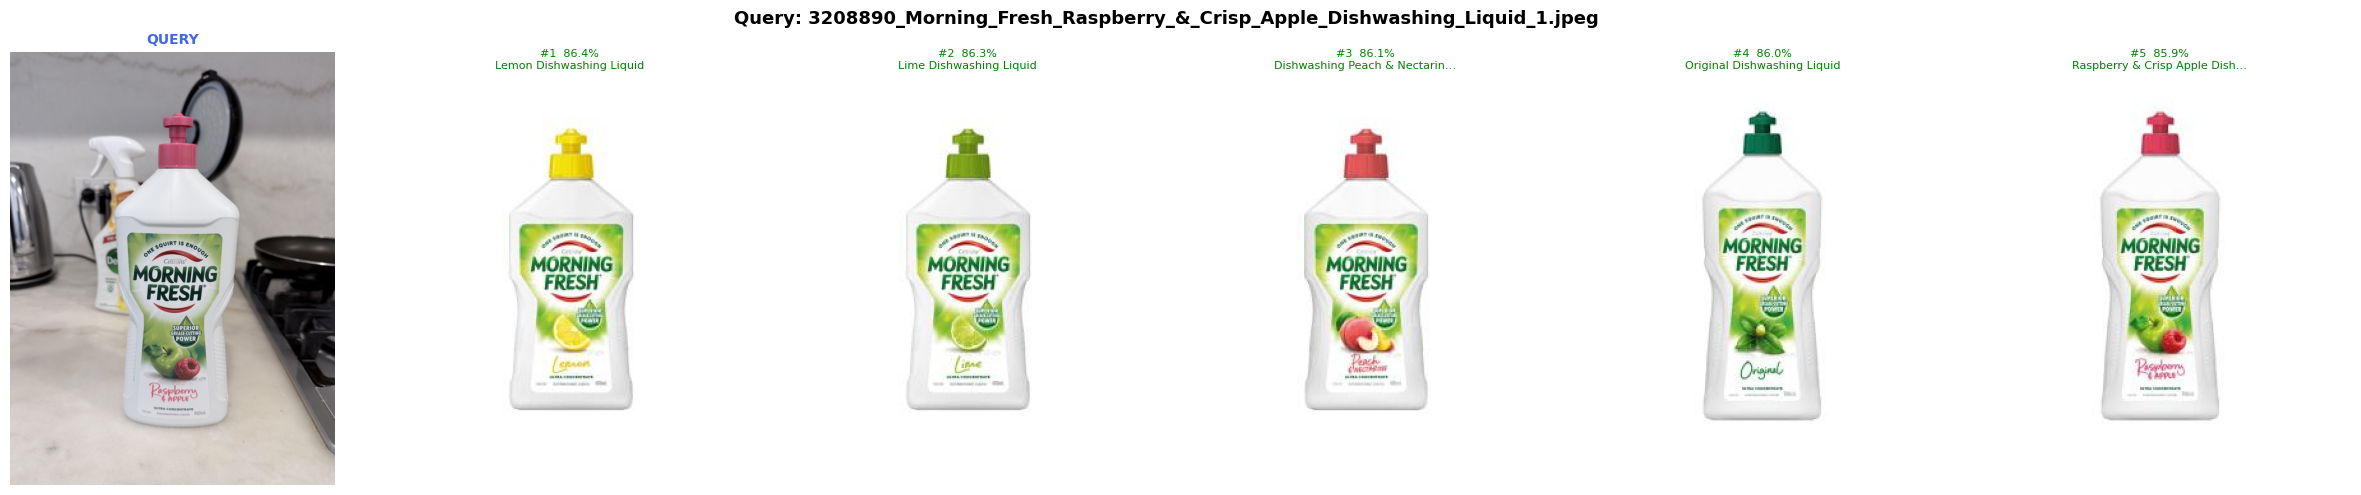

,Score,GTIN,Product,View,Augment,product_id
Rank,,,,,,
1,0.8644,9300615055909,Lemon Dishwashing Liquid,main,centre_zoom,2225395
2,0.8627,9300615055800,Lime Dishwashing Liquid,main,centre_zoom,2225329
3,0.8605,9300615115429,Dishwashing Peach & Nectarine,main,centre_zoom,6318181
4,0.8601,9300615055671,Original Dishwashing Liquid,main,centre_zoom,9736075
5,0.8585,9300615582306,Raspberry & Crisp Apple Dishwashing Liquid,main,centre_zoom,3208890



──────────────────────────────────────────────────────────────────────
🔍  Querying: 4256516_Dettol_Disinfectant_Citrus_Multipurpose_Surface_Cleaning_Spray_1.jpeg


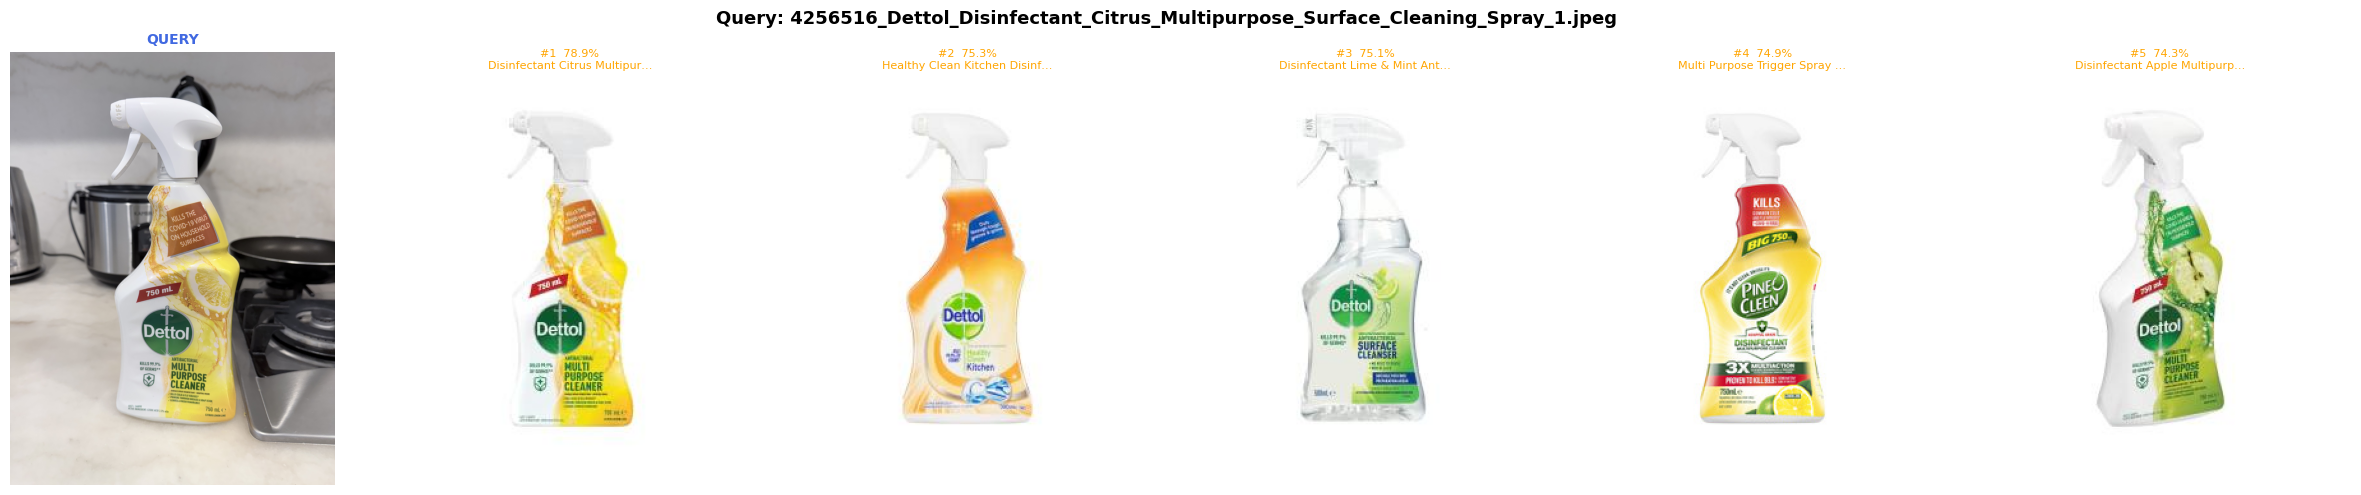

,Score,GTIN,Product,View,Augment,product_id
Rank,,,,,,
1,0.7886,9300631432418,Disinfectant Citrus Multipurpose Surface Clean...,main,normal,4256516
2,0.7526,9300701106560,Healthy Clean Kitchen Disinfectant Surface Cle...,main,saturate,2454439
3,0.7512,9300631753483,Disinfectant Lime & Mint Antibacterial Surface...,main,centre_zoom,7909999
4,0.7486,9300701488819,Multi Purpose Trigger Spray Lemon Lime,right,normal,1974138
5,0.7435,9300631432104,Disinfectant Apple Multipurpose Surface Cleani...,left,normal,4256505



──────────────────────────────────────────────────────────────────────
🔍  Querying: 5229257_Spam_Lite_Spiced_Ham_1.jpeg


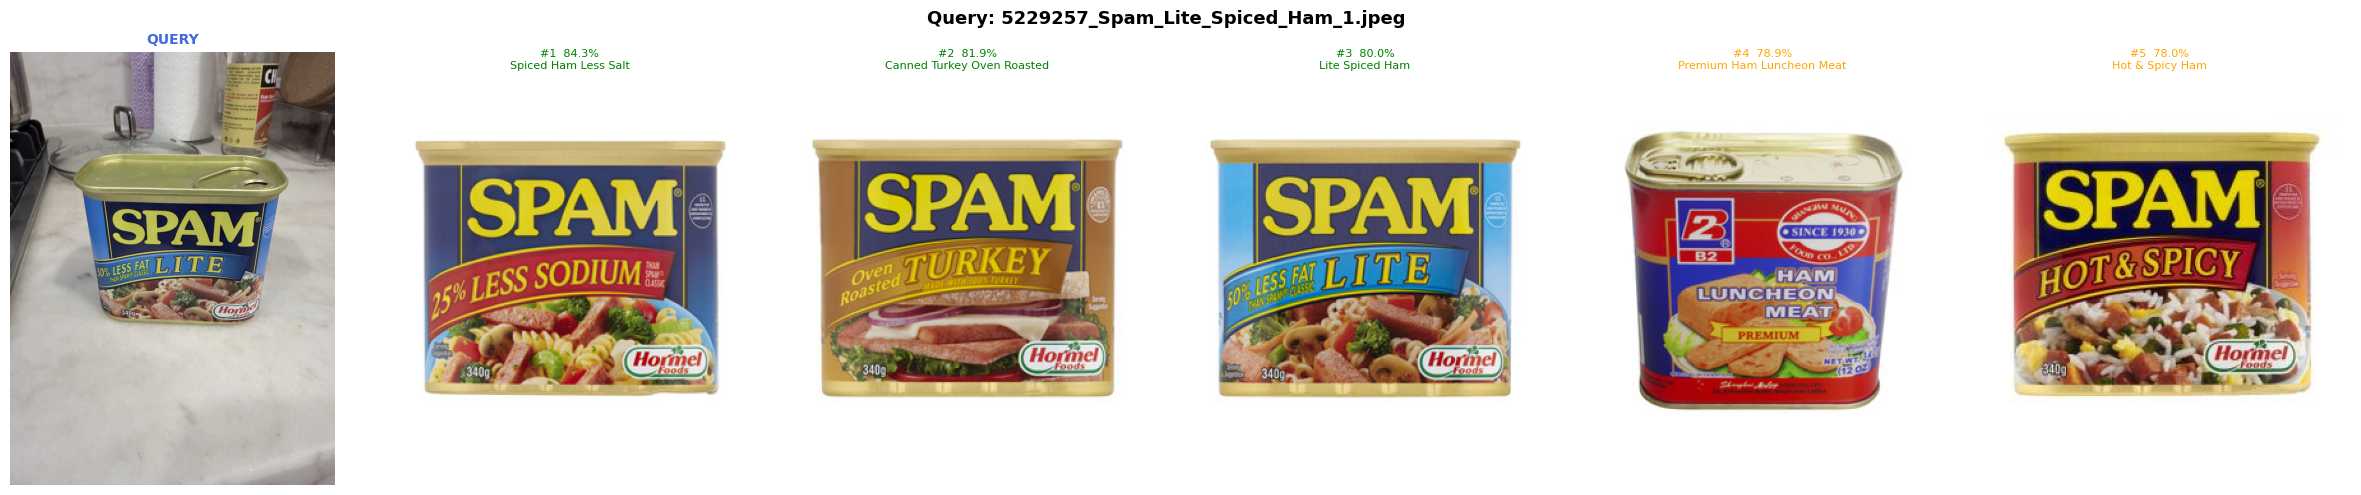

,Score,GTIN,Product,View,Augment,product_id
Rank,,,,,,
1,0.8432,UNKNOWN,Spiced Ham Less Salt,main,blur,399250
2,0.8190,UNKNOWN,Canned Turkey Oven Roasted,main,blur,8793776
3,0.8004,UNKNOWN,Lite Spiced Ham,main,flipped,5229257
4,0.7890,6902131111294,Premium Ham Luncheon Meat,main,saturate,1383153
5,0.7796,UNKNOWN,Hot & Spicy Ham,main,blur,9040263



──────────────────────────────────────────────────────────────────────
🔍  Querying: 5441863_Pepsi_Max_No_Sugar_Cola_Soft_Drink_Bottle_1.jpeg


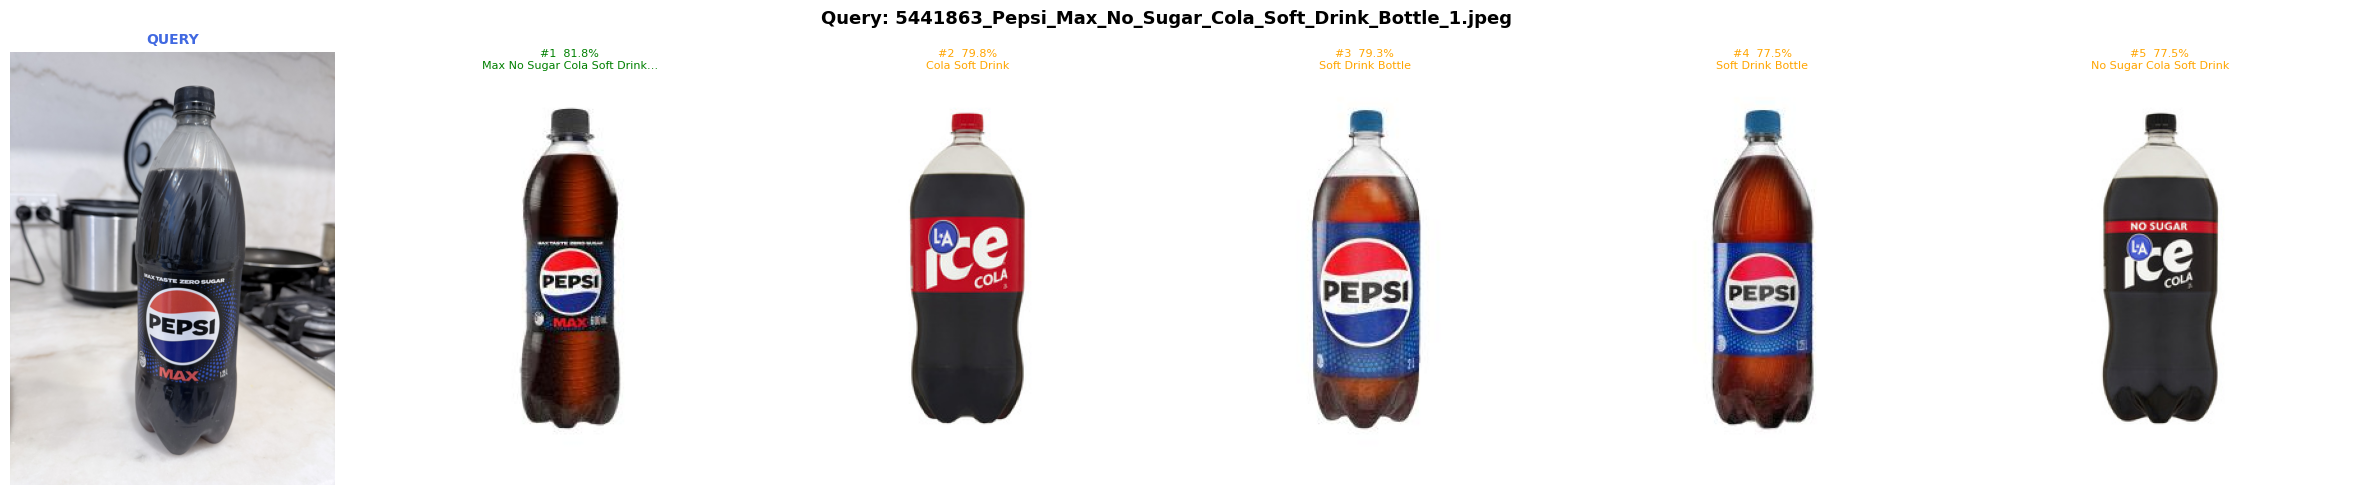

,Score,GTIN,Product,View,Augment,product_id
Rank,,,,,,
1,0.8184,9313820000862,Max No Sugar Cola Soft Drink Bottle,main,centre_zoom,9107681
2,0.7981,9345905000092,Cola Soft Drink,main,saturate,2506339
3,0.7931,9313820004051,Soft Drink Bottle,main,normal,1310310
4,0.7754,9313820004044,Soft Drink Bottle,main,saturate,1310309
5,0.7750,9345905008227,No Sugar Cola Soft Drink,main,saturate,3813639



──────────────────────────────────────────────────────────────────────
🔍  Querying: 7523018_Coles_Simply_Spaghetti_In_Tomato_Sauce_1.jpeg


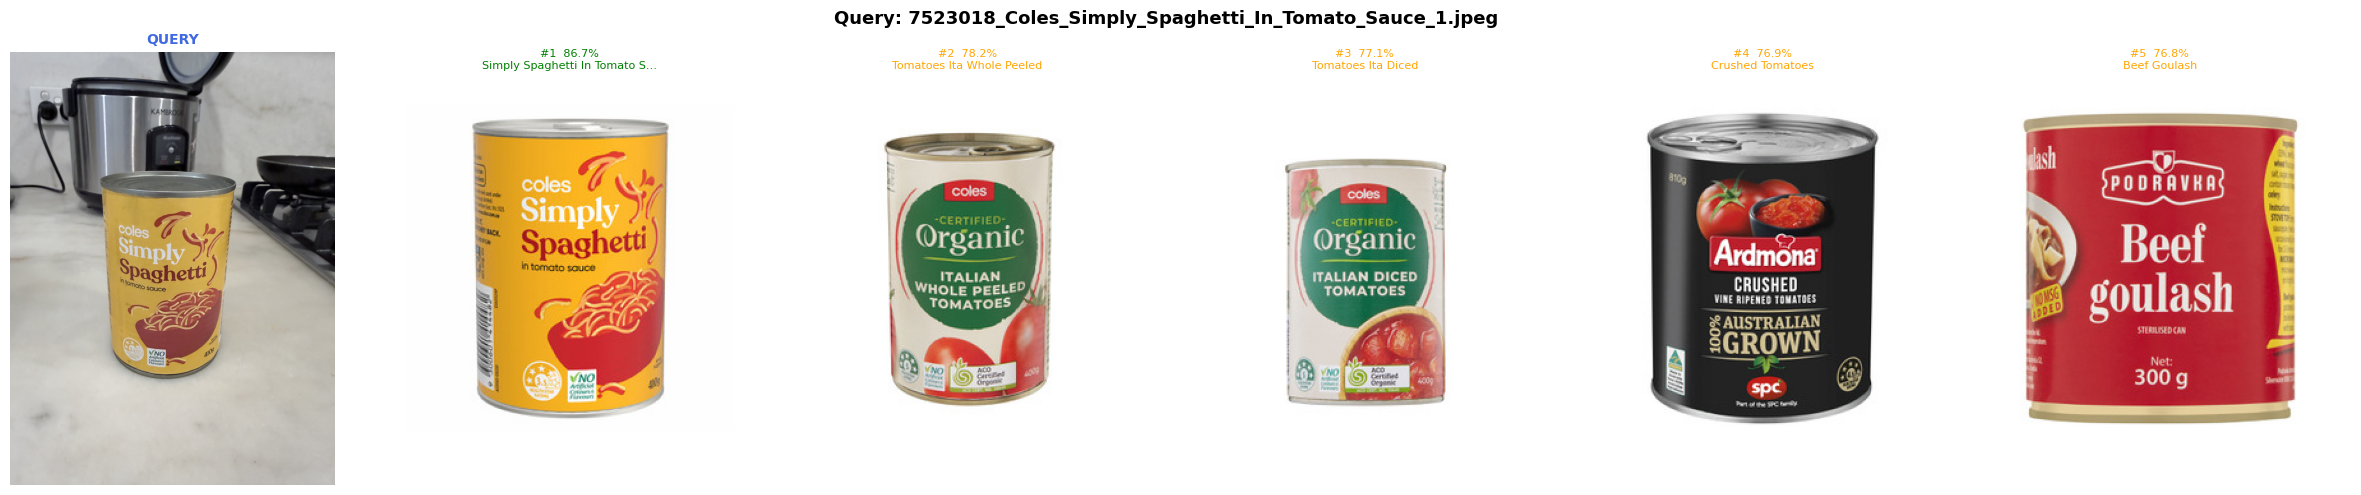

,Score,GTIN,Product,View,Augment,product_id
Rank,,,,,,
1,0.8674,9300601414482,Simply Spaghetti In Tomato Sauce,back,normal,7523018
2,0.7820,9300601201532,Tomatoes Ita Whole Peeled,left,normal,9388650
3,0.7711,9300601201563,Tomatoes Ita Diced,main,flipped,9388660
4,0.7687,9310092228628,Crushed Tomatoes,main,flipped,6393868
5,0.7680,9322715020069,Beef Goulash,main,saturate,6331496


: 

In [21]:
# Run each test image through the pipeline and display results
TOP_K = 5
all_results_summary = []   # collects per-image summary for the scorecard below

for img_path in test_images:
    print(f"{'─'*70}")
    print(f"🔍  Querying: {img_path.name}")
    try:
        results = query_product(
            image_path   = str(img_path),
            index_path   = INDEX_PATH,
            meta_path    = METADATA_PATH,
            top_k        = TOP_K,
            device       = DEVICE,
            _model       = model,
            _index_cache = (faiss_index, faiss_metadata),
        )
        show_query_results(img_path, results)
        all_results_summary.append({
            "image":          img_path.name,
            "top1_name":      results[0]["name"] if results else "—",
            "top1_score":     results[0]["similarity_score"] if results else 0.0,
            "top1_product_id": results[0]["product_id"] if results else "—",
        })
    except Exception as exc:
        print(f"  ❌ Error: {exc}")
        all_results_summary.append({
            "image": img_path.name, "top1_name": "ERROR",
            "top1_score": 0.0, "top1_product_id": "—",
        })

### Summary Scorecard

Top-1 result for each test image — sorted by similarity score. A score ≥ 0.80 is a strong cosine match.

,Test Image,Top-1 Match,Cosine Score,Product ID
1,7523018_Coles_Simply_Spaghetti_In_Tomato_Sauce...,Simply Spaghetti In Tomato Sauce,0.8674,7523018
2,3208890_Morning_Fresh_Raspberry_&_Crisp_Apple_...,Lemon Dishwashing Liquid,0.8644,2225395
3,5229257_Spam_Lite_Spiced_Ham_1.jpeg,Spiced Ham Less Salt,0.8432,399250
4,5441863_Pepsi_Max_No_Sugar_Cola_Soft_Drink_Bot...,Max No Sugar Cola Soft Drink Bottle,0.8184,9107681
5,4256516_Dettol_Disinfectant_Citrus_Multipurpos...,Disinfectant Citrus Multipurpose Surface Clean...,0.7886,4256516
6,1251527_Cocobella_Coconut_Water_Straight_Up_1....,Coconut Water Straight Up,0.7336,1251527


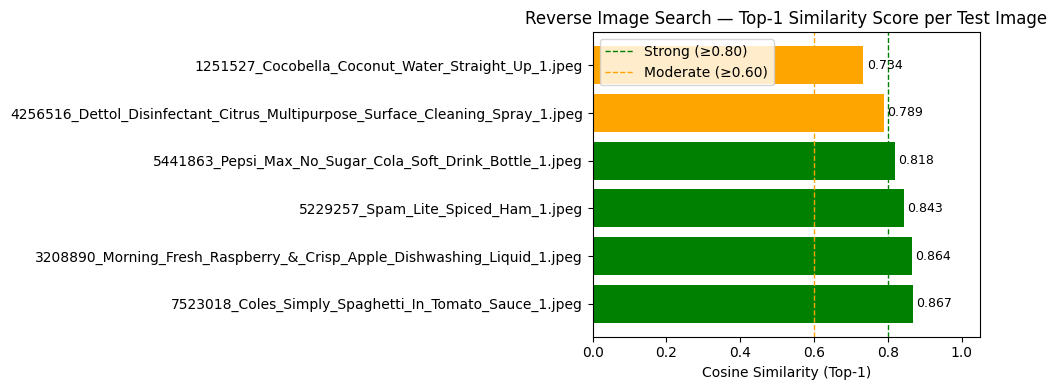

: 

In [22]:
summary_df = pd.DataFrame(all_results_summary)
summary_df["top1_score"] = summary_df["top1_score"].round(4)
summary_df = summary_df.sort_values("top1_score", ascending=False).reset_index(drop=True)
summary_df.index += 1

display(summary_df.rename(columns={
    "image": "Test Image",
    "top1_name": "Top-1 Match",
    "top1_score": "Cosine Score",
    "top1_product_id": "Product ID",
}))

# Score distribution bar chart
fig, ax = plt.subplots(figsize=(10, 4))
colours = ["green" if s >= 0.80 else ("orange" if s >= 0.60 else "tomato")
           for s in summary_df["top1_score"]]
bars = ax.barh(summary_df["image"], summary_df["top1_score"], color=colours)
ax.axvline(0.80, color="green",  linestyle="--", linewidth=1, label="Strong (≥0.80)")
ax.axvline(0.60, color="orange", linestyle="--", linewidth=1, label="Moderate (≥0.60)")
ax.set_xlabel("Cosine Similarity (Top-1)")
ax.set_title("Reverse Image Search — Top-1 Similarity Score per Test Image")
ax.set_xlim(0, 1.05)
ax.legend()
for bar, score in zip(bars, summary_df["top1_score"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{score:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

### Deduplication — unique products in top-5

The raw top-5 results often contain multiple augmentations of the same product. This cell re-runs each query and collapses duplicates to show the top-5 **unique** products.

In [24]:
# Deduplication is now handled inside query_product via Score Aggregation.
# This cell simply re-displays the top-5 unique products in plain text for easy reading.

print("Top-5 UNIQUE products per test image\n")

for img_path in test_images:
    try:
        results = query_product(
            image_path   = str(img_path),
            top_k        = 5,
            device       = DEVICE,
            _model       = model,
            _index_cache = (faiss_index, faiss_metadata),
        )
        print(f"📷  {img_path.name}")
        for r in results:
            print(f"   #{r['rank']}  {r['similarity_score']:.4f}  [{r['product_id']}]  {r['name'][:60]}")
        print()
    except Exception as exc:
        print(f"  ❌ {img_path.name}: {exc}\n")

Top-5 UNIQUE products per test image

📷  1251527_Cocobella_Coconut_Water_Straight_Up_1.jpeg
   #1  0.7336  [1251527]  Coconut Water Straight Up
   #2  0.6680  [6935042]  Smoothie Starter
   #3  0.6638  [2586768]  Watermelon & Mint Flavour Coconut Water
   #4  0.6389  [1051991]  Flavoured Coconut Water Coffee
   #5  0.6353  [2819855]  Chocolate Flavoured Coconut Water

📷  3208890_Morning_Fresh_Raspberry_&_Crisp_Apple_Dishwashing_Liquid_1.jpeg
   #1  0.8644  [2225395]  Lemon Dishwashing Liquid
   #2  0.8627  [2225329]  Lime Dishwashing Liquid
   #3  0.8605  [6318181]  Dishwashing Peach & Nectarine
   #4  0.8601  [9736075]  Original Dishwashing Liquid
   #5  0.8585  [3208890]  Raspberry & Crisp Apple Dishwashing Liquid

📷  4256516_Dettol_Disinfectant_Citrus_Multipurpose_Surface_Cleaning_Spray_1.jpeg
   #1  0.7886  [4256516]  Disinfectant Citrus Multipurpose Surface Cleaning Spray
   #2  0.7526  [2454439]  Healthy Clean Kitchen Disinfectant Surface Cleaning Spray
   #3  0.7512  [7909999]  

: 